<a href="https://colab.research.google.com/github/nooryashfa72-create/BFS-LAB-/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# yashfa noor
# SP24-BSE-178
# LAB ASSIGNMENT : AI **O1**

In [ ]:
# Task 1: BFS and DFS on a Tree
# We represent a tree as a dictionary (adjacency list)
# Each key is a node, each value is a list of its children

from collections import deque  # deque is used for the queue in BFS

# Our example tree:
#        1
#      /   \
#     2     3
#    / \   / \
#   4   5 6   7

tree = {
    1: [2, 3],
    2: [4, 5],
    3: [6, 7],
    4: [],
    5: [],
    6: [],
    7: []
}

# ---- BFS (Breadth-First Search) ----
# Uses a Queue: visit level by level
def bfs(graph, start):
    visited = []
    queue = deque([start])  # start with the root in the queue

    while queue:
        node = queue.popleft()       # take from the FRONT
        visited.append(node)
        for neighbor in graph[node]: # add children to the back
            queue.append(neighbor)

    return visited

# ---- DFS (Depth-First Search) ----
# Uses a Stack: dive deep before going wide
def dfs(graph, start):
    visited = []
    stack = [start]  # start with the root in the stack

    while stack:
        node = stack.pop()           # take from the TOP
        visited.append(node)
        for neighbor in reversed(graph[node]):  # reversed to keep left-to-right order
            stack.append(neighbor)

    return visited

# ---- Run it ----
print("BFS order:", bfs(tree, 1))
print("DFS order:", dfs(tree, 1))

BFS order: [1, 2, 3, 4, 5, 6, 7]
DFS order: [1, 2, 4, 5, 3, 6, 7]


# TASK 02

Tree Size    BFS Time (ms)    DFS Time (ms)
1000         0.112            0.098
40000        8.327            8.038
80000        20.597           18.252
200000       88.246           57.208
1000000      944.472          577.474


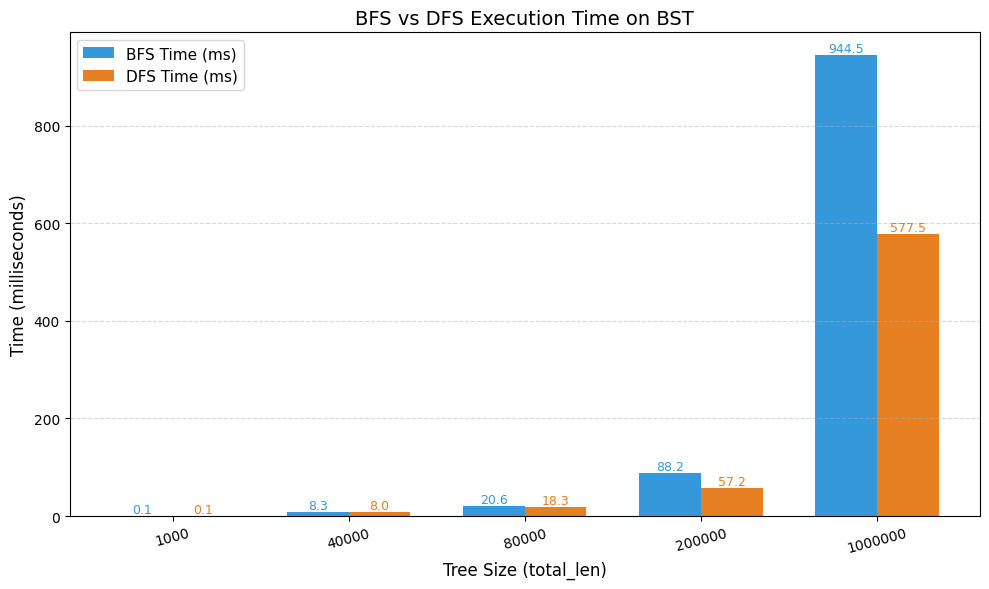

In [ ]:
import random
import time
import matplotlib.pyplot as plt
from collections import deque

# ================================================
# STEP 1: Build a Binary Search Tree (BST)
# ================================================

class Node:
    def __init__(self, value):
        self.value = value
        self.left = None
        self.right = None

class BST:
    def __init__(self):
        self.root = None

    def insert(self, value):
        if self.root is None:
            self.root = Node(value)
        else:
            self._insert(self.root, value)

    def _insert(self, node, value):
        if value < node.value:
            if node.left is None:
                node.left = Node(value)
            else:
                self._insert(node.left, value)
        else:
            if node.right is None:
                node.right = Node(value)
            else:
                self._insert(node.right, value)

# ================================================
# STEP 2: BFS on the BST
# ================================================

def bfs(root):
    if root is None:
        return
    queue = deque([root])
    while queue:
        node = queue.popleft()
        if node.left:
            queue.append(node.left)
        if node.right:
            queue.append(node.right)

# ================================================
# STEP 3: DFS on the BST
# ================================================

def dfs(root):
    if root is None:
        return
    stack = [root]
    while stack:
        node = stack.pop()
        if node.right:
            stack.append(node.right)
        if node.left:
            stack.append(node.left)

# ================================================
# STEP 4: Generate 5 datasets & measure time
# ================================================

sizes = [1000, 40000, 80000, 200000, 1000000]

bfs_times = []
dfs_times = []

print("=" * 45)
print(f"{'Tree Size':<12} {'BFS Time (ms)':<16} {'DFS Time (ms)'}")
print("=" * 45)

for size in sizes:
    # Generate unique random numbers
    numbers = random.sample(range(1, size * 10), size)

    # Build the BST
    tree = BST()
    for num in numbers:
        tree.insert(num)

    # Measure BFS time
    start = time.time()
    bfs(tree.root)
    bfs_time = (time.time() - start) * 1000  # convert to ms

    # Measure DFS time
    start = time.time()
    dfs(tree.root)
    dfs_time = (time.time() - start) * 1000  # convert to ms

    bfs_times.append(round(bfs_time, 3))
    dfs_times.append(round(dfs_time, 3))

    print(f"{size:<12} {round(bfs_time, 3):<16} {round(dfs_time, 3)}")

print("=" * 45)

# ================================================
# STEP 5: Plot the Bar Chart
# ================================================

x = range(len(sizes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar([i - width/2 for i in x], bfs_times, width,
               label='BFS Time (ms)', color='#3498DB')
bars2 = ax.bar([i + width/2 for i in x], dfs_times, width,
               label='DFS Time (ms)', color='#E67E22')

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=9, color='#3498DB')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=9, color='#E67E22')

# Labels and formatting
ax.set_xlabel('Tree Size (total_len)', fontsize=12)
ax.set_ylabel('Time (milliseconds)', fontsize=12)
ax.set_title('BFS vs DFS Execution Time on BST', fontsize=14)
ax.set_xticks(list(x))
ax.set_xticklabels([str(s) for s in sizes], rotation=15)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# TASK : 03


🚌 Finding shortest path from Islamabad to Karachi...

       BFS STEP BY STEP TRAVERSAL
Step 1: Visiting --> Islamabad
         Path so far: Islamabad

Step 2: Visiting --> Rawalpindi
         Path so far: Islamabad → Rawalpindi

Step 3: Visiting --> Lahore
         Path so far: Islamabad → Lahore

Step 4: Visiting --> Peshawar
         Path so far: Islamabad → Peshawar

Step 5: Visiting --> Quetta
         Path so far: Islamabad → Rawalpindi → Quetta

Step 6: Visiting --> Multan
         Path so far: Islamabad → Lahore → Multan

Step 7: Visiting --> Karachi
         Path so far: Islamabad → Rawalpindi → Quetta → Karachi

🎯 GOAL REACHED: Karachi

✅ Shortest Path Found:
   Islamabad → Rawalpindi → Quetta → Karachi

📏 Total cities visited : 4
🛣️  Total hops (edges)   : 3


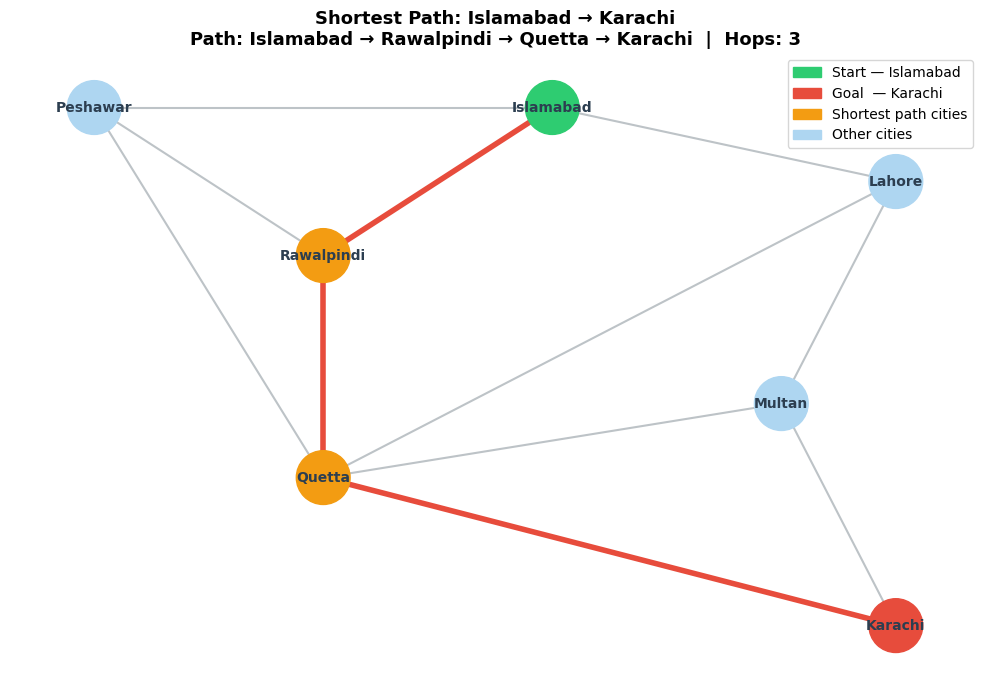

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from collections import deque

# ================================================
# STEP 1: Build the City Graph
# ================================================

graph = {
    'Islamabad'  : ['Rawalpindi', 'Lahore', 'Peshawar'],
    'Rawalpindi' : ['Islamabad', 'Peshawar', 'Quetta'],
    'Peshawar'   : ['Islamabad', 'Rawalpindi', 'Quetta'],
    'Lahore'     : ['Islamabad', 'Multan', 'Quetta'],
    'Multan'     : ['Lahore', 'Karachi', 'Quetta'],
    'Quetta'     : ['Rawalpindi', 'Peshawar', 'Multan', 'Karachi'],
    'Karachi'    : ['Multan', 'Quetta']
}

# ================================================
# STEP 2: BFS — Find Shortest Path
# ================================================

def bfs_shortest_path(graph, start, goal):

    # Queue stores (current_city, path_so_far)
    queue   = deque([(start, [start])])
    visited = set([start])

    print("=" * 55)
    print("       BFS STEP BY STEP TRAVERSAL")
    print("=" * 55)
    step = 1

    while queue:

        city, path = queue.popleft()

        print(f"Step {step}: Visiting --> {city}")
        print(f"         Path so far: {' → '.join(path)}")
        print()
        step += 1

        # ✅ Goal reached!
        if city == goal:
            print("=" * 55)
            print(f"🎯 GOAL REACHED: {goal}")
            print("=" * 55)
            return path

        # Add all unvisited neighbors to queue
        for neighbor in graph[city]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))

    return None   # no path found

# ================================================
# STEP 3: Run BFS from Islamabad to Karachi
# ================================================

start = 'Islamabad'
goal  = 'Karachi'

print(f"\n🚌 Finding shortest path from {start} to {goal}...\n")

shortest_path = bfs_shortest_path(graph, start, goal)

print(f"\n✅ Shortest Path Found:")
print(f"   {' → '.join(shortest_path)}")
print(f"\n📏 Total cities visited : {len(shortest_path)}")
print(f"🛣️  Total hops (edges)   : {len(shortest_path) - 1}")

# ================================================
# STEP 4: Draw the Graph
# Highlight the shortest path in color
# ================================================

G = nx.Graph()

# Add all edges
for city, neighbors in graph.items():
    for neighbor in neighbors:
        G.add_edge(city, neighbor)

# Fixed positions (roughly matching Pakistan geography)
positions = {
    'Peshawar'   : (0.0, 3.5),
    'Islamabad'  : (2.0, 3.5),
    'Rawalpindi' : (1.0, 2.5),
    'Lahore'     : (3.5, 3.0),
    'Quetta'     : (1.0, 1.0),
    'Multan'     : (3.0, 1.5),
    'Karachi'    : (3.5, 0.0),
}

# Build shortest path edges
path_edges = []
for i in range(len(shortest_path) - 1):
    path_edges.append((shortest_path[i], shortest_path[i+1]))

# All other edges
other_edges = [e for e in G.edges() if e not in path_edges
               and (e[1], e[0]) not in path_edges]

# Node colors
node_colors = []
for node in G.nodes():
    if node == start:
        node_colors.append('#2ECC71')    # green  = start
    elif node == goal:
        node_colors.append('#E74C3C')    # red    = goal
    elif node in shortest_path:
        node_colors.append('#F39C12')    # orange = on path
    else:
        node_colors.append('#AED6F1')    # blue   = not on path

plt.figure(figsize=(10, 7))

# Draw normal edges
nx.draw_networkx_edges(G, positions,
                       edgelist=other_edges,
                       width=1.5,
                       edge_color='#BDC3C7')

# Draw shortest path edges (thick + colored)
nx.draw_networkx_edges(G, positions,
                       edgelist=path_edges,
                       width=4.0,
                       edge_color='#E74C3C',
                       style='solid')

# Draw nodes
nx.draw_networkx_nodes(G, positions,
                       node_color=node_colors,
                       node_size=1500)

# Draw labels
nx.draw_networkx_labels(G, positions,
                        font_size=10,
                        font_weight='bold',
                        font_color='#2C3E50')

# Legend
legend = [
    mpatches.Patch(color='#2ECC71', label='Start — Islamabad'),
    mpatches.Patch(color='#E74C3C', label='Goal  — Karachi'),
    mpatches.Patch(color='#F39C12', label='Shortest path cities'),
    mpatches.Patch(color='#AED6F1', label='Other cities'),
]
plt.legend(handles=legend, loc='upper right', fontsize=10)

plt.title(
    f'Shortest Path: Islamabad → Karachi\n'
    f'Path: {" → ".join(shortest_path)}  |  Hops: {len(shortest_path)-1}',
    fontsize=13, fontweight='bold'
)

plt.axis('off')
plt.tight_layout()
plt.show()